In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df=pd.read_csv('ins.csv')

In [ ]:
df.head()

,age,sex,bmi,smoker,region,charges
0,19,female,27.900,yes,southwest,16884.92400
1,18,male,33.770,no,southeast,1725.55230
2,28,male,33.000,no,southeast,4449.46200
3,33,male,22.705,no,northwest,21984.47061
4,32,male,28.880,no,northwest,3866.85520


In [ ]:
print('shape:',df.shape)

shape: (1338, 6)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      1338 non-null   int64  
 1   sex      1338 non-null   object 
 2   bmi      1338 non-null   float64
 3   smoker   1338 non-null   object 
 4   region   1338 non-null   object 
 5   charges  1338 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 62.8+ KB


In [ ]:
df.describe()

,age,bmi,charges
count,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,13270.422265
std,14.049960,6.098187,12110.011237
min,18.000000,15.960000,1121.873900
25%,27.000000,26.296250,4740.287150
50%,39.000000,30.400000,9382.033000
75%,51.000000,34.693750,16639.912515
max,64.000000,53.130000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
smoker,0
region,0
charges,0


In [ ]:
le=LabelEncoder() #convert everything to 0 1
df['sex']=le.fit_transform(df['sex']) #female=0,male=1
df['smoker']=le.fit_transform(df['smoker']) #no=0,yes=1
df['region']=le.fit_transform(df['region']) #northeast=0,northwesr=1,southeast=2,southwest=3

In [ ]:
df.head()

,age,sex,bmi,smoker,region,charges
0,19,0,27.900,1,3,16884.92400
1,18,1,33.770,0,2,1725.55230
2,28,1,33.000,0,2,4449.46200
3,33,1,22.705,0,1,21984.47061
4,32,1,28.880,0,1,3866.85520


In [ ]:
#Q1. regression-predicting insurance charges()
#feature/target
x=df.drop('charges',axis=1)
y=df['charges']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training samples:",x_train.shape)
print("Testing samples:",x_test.shape)

Training samples: (1070, 5)
Testing samples: (268, 5)


In [ ]:
#features transform krta hain jo jo relevant hain usme ....it brings teh whole data set in a standard form and bring it in same range
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
#build the regression neural network
model=Sequential([
Dense(64,activation='relu',input_shape=(x_train.shape[1],)),
Dense(32,activation='relu'),# 32 and 62 are weights that are neurons connected to each other
Dense(32,activation='relu'),
Dense(1)#linear output=predicyts continuous charge value
])
model.summary()#to print summary


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,553 (13.88 KB)

 Trainable params: 3,553 (13.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#hyperparameter compile
model.compile(
    optimizer='adam',#optimizer
    loss='mean_squared_error',#l2/mean squared error
    metrics=['mae']#mean abosluted error for interpretability
)


In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=60, # to run 1 particular feature for 60 times
    batch_size=32, # if you inc the size   grps decrease and vice versa
    validation_split=0.2,# trains 20% of the data
    verbose=1 # to display progress
    )

Epoch 1/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 325439136.0000 - mae: 13517.4941 - val_loss: 310301920.0000 - val_mae: 12652.8936
Epoch 2/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 325320064.0000 - mae: 13513.2012 - val_loss: 310097696.0000 - val_mae: 12645.0420
Epoch 3/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 324891424.0000 - mae: 13498.6328 - val_loss: 309415520.0000 - val_mae: 12620.4170
Epoch 4/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 323642496.0000 - mae: 13457.3535 - val_loss: 307575296.0000 - val_mae: 12557.7207
Epoch 5/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 320593984.0000 - mae: 13359.7617 - val_loss: 303371648.0000 - val_mae: 12420.9863
Epoch 6/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 314234208.0000 - mae: 13164.1719 - val_loss: 295169440.0000 - val_mae: 12163.4209
Epoch 7/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 301982496.0000 - mae: 12810.7041 - val_loss: 281094560.0000 - val_mae: 11724.4209
Epoch 8/60
27/27 ━━

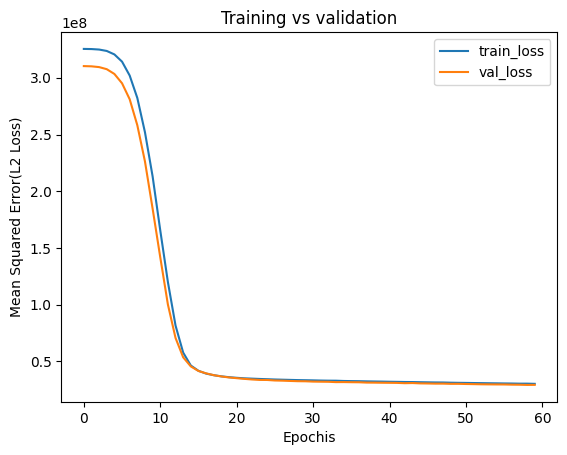

In [ ]:
#to plot
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('Epochis')
plt.ylabel('Mean Squared Error(L2 Loss)')
plt.title('Training vs validation')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


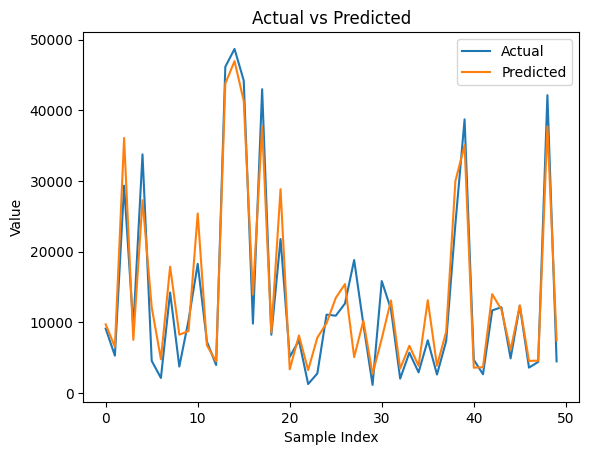

In [ ]:
#actual vs predicted
y_pred=model.predict(x_test).flatten()
plt.figure()
plt.plot(y_test.values[:50],label='Actual')
plt.plot(y_pred[:50],label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()


In [ ]:
import sklearn.metrics as metrics
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)

R2 Score: 0.8193904948787996


In [ ]:
df2=pd.read_csv('ins.csv')

In [ ]:
df2.head()

,age,sex,bmi,smoker,region,charges
0,19,female,27.900,yes,southwest,16884.92400
1,18,male,33.770,no,southeast,1725.55230
2,28,male,33.000,no,southeast,4449.46200
3,33,male,22.705,no,northwest,21984.47061
4,32,male,28.880,no,northwest,3866.85520


In [ ]:
le2=LabelEncoder() #convert everything to 0 1
df2['sex']=le2.fit_transform(df2['sex']) #female=0,male=1
df2['smoker']=le2.fit_transform(df2['smoker']) #no=0,yes=1
df2['region']=le2.fit_transform(df2['region']) #northeast=0,northwesr=1,southeast=2,southwest=3

In [ ]:
median_charge = df["charges"].median()
print("Median Charge:", median_charge)
df2["high_cost"]=(df2["charges"]>median_charge).astype(int)
print("\nClass Distribution:")
print(df2["high_cost"].value_counts())

Median Charge: 9382.033

Class Distribution:
high_cost
1    669
0    669
Name: count, dtype: int64


In [ ]:
# feature split target train
x2 = df2.drop(["charges", "high_cost"], axis=1)
y2 = df2["high_cost"]
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
print("Training",x_train.shape[0])
print("Testing",x_test.shape[0])

Training 1070
Testing 268


In [ ]:
clf_model=Sequential([
Dense(64,activation='relu',input_shape=(x_train.shape[1],)),
Dense(32,activation='relu'),# 32 and 62 are weights that are neurons connected to each other
Dense(1)#linear output=predicyts continuous charge value
])
model.summary()#to print summary

In [ ]:
#hyperparameter compile
model.compile(
    optimizer='adam',#optimizer
    loss='mean_squared_error',#l2/mean squared error
    metrics=['mae']#mean abosluted error for interpretability
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=60, # to run 1 particular feature for 60 times
    batch_size=32, # if you inc the size   grps decrease and vice versa
    validation_split=0.2,# trains 20% of the data
    verbose=1 # to display progress
    )

Epoch 1/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 30231674.0000 - mae: 3628.1433 - val_loss: 29243342.0000 - val_mae: 3542.9783
Epoch 2/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 30084458.0000 - mae: 3613.6101 - val_loss: 29004036.0000 - val_mae: 3529.2617
Epoch 3/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 30030990.0000 - mae: 3595.1240 - val_loss: 28941462.0000 - val_mae: 3501.9915
Epoch 4/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 29974782.0000 - mae: 3583.7351 - val_loss: 28746686.0000 - val_mae: 3509.4346
Epoch 5/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29808228.0000 - mae: 3563.6057 - val_loss: 28766732.0000 - val_mae: 3503.1960
Epoch 6/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29732388.0000 - mae: 3557.6230 - val_loss: 28628672.0000 - val_mae: 3493.1360
Epoch 7/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29716984.0000 - mae: 3592.3367 - val_loss: 28416978.0000 - val_mae: 3506.8188
Epoch 8/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms

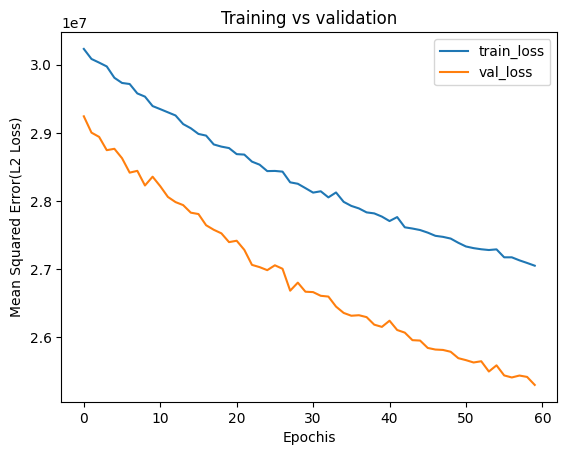

In [ ]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('Epochis')
plt.ylabel('Mean Squared Error(L2 Loss)')
plt.title('Training vs validation')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


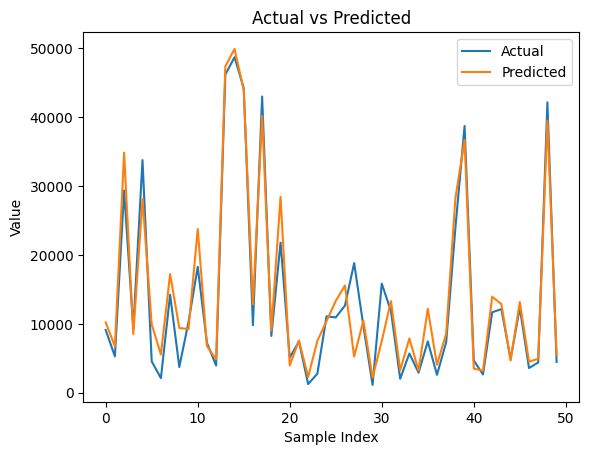

In [ ]:
y_pred=model.predict(x_test).flatten()
plt.figure()
plt.plot(y_test.values[:50],label='Actual')
plt.plot(y_pred[:50],label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()